In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


In [3]:
df = pd.read_csv("../data/car_features.csv")

df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [ ]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [8]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [9]:
# remove unnecessary columns
df = df.drop(["Market Category"], axis = 1)

# handle missing values

df["Engine HP"] = df["Engine HP"].fillna(df["Engine HP"].median())
df["Engine Cylinders"] = df["Engine Cylinders"].fillna(df["Engine Cylinders"].median())
df["Number of Doors"] = df["Number of Doors"].fillna(df["Number of Doors"].mode()[0])
df["Engine Fuel Type"] = df["Engine Fuel Type"].fillna("Unknown")

df.isnull().sum()


Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64

In [10]:
features = df[[
    "Engine HP",
    "Engine Cylinders",
    "highway MPG",
    "city mpg", 
    "Popularity",
    "MSRP",
    
    ]]

features.head()

,Engine HP,Engine Cylinders,highway MPG,city mpg,Popularity,MSRP
0,335.0,6.0,26,19,3916,46135
1,300.0,6.0,28,19,3916,40650
2,300.0,6.0,28,20,3916,36350
3,230.0,6.0,28,18,3916,29450
4,230.0,6.0,28,18,3916,34500


In [12]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 7.87477300e-01,  2.08192460e-01, -7.19295962e-02,
        -8.15868087e-02,  1.63760387e+00,  9.21739830e-02],
       [ 4.66033924e-01,  2.08192460e-01,  1.53737082e-01,
        -8.15868087e-02,  1.63760387e+00,  9.19416262e-04],
       [ 4.66033924e-01,  2.08192460e-01,  1.53737082e-01,
         2.96798166e-02,  1.63760387e+00, -7.06201711e-02],
       [-1.76852828e-01,  2.08192460e-01,  1.53737082e-01,
        -1.92853434e-01,  1.63760387e+00, -1.85416253e-01],
       [-1.76852828e-01,  2.08192460e-01,  1.53737082e-01,
        -1.92853434e-01,  1.63760387e+00, -1.01398831e-01]])

In [13]:
model = NearestNeighbors(n_neighbors=6, metric = "euclidean")
model.fit(scaled_features)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [18]:
def recommend_cars(car_index):
    distances, indices = model.kneighbors([scaled_features[car_index]])

    print("Selected Car:")
    print(df.iloc[car_index][["Make", "Model", "MSRP", "Engine HP"]])
    print("\nRecommend Cars:\n")

    for i in indices[0][1:]:
        print(df.iloc[i][["Make", "Model", "MSRP", "Engine HP"]])
        print("-" * 40)

In [19]:
recommend_cars(10)

Selected Car:
Make              BMW
Model        1 Series
MSRP            39600
Engine HP       300.0
Name: 10, dtype: object

Recommend Cars:

Make              BMW
Model        1 Series
MSRP            39300
Engine HP       300.0
Name: 7, dtype: object
----------------------------------------
Make              BMW
Model        1 Series
MSRP            36350
Engine HP       300.0
Name: 2, dtype: object
----------------------------------------
Make              BMW
Model        1 Series
MSRP            40650
Engine HP       300.0
Name: 1, dtype: object
----------------------------------------
Make              BMW
Model        1 Series
MSRP            44400
Engine HP       300.0
Name: 12, dtype: object
----------------------------------------
Make              BMW
Model        1 Series
MSRP            43550
Engine HP       320.0
Name: 16, dtype: object
----------------------------------------


In [29]:
def get_car_index(make, model):
    result = df[(df["Make"] == make) & (df["Model"] == model)]

    if len(result) == 0:
        print("Car not found")
        return None
    
    return result.index[0]

In [30]:
def recommend_by_name(make, model):
    car_index = get_car_index(make, model)

    if car_index is None:
        return
    recommend_cars(car_index)

In [31]:
recommend_by_name("BMW", "1 Series")

Selected Car:
Make              BMW
Model        1 Series
MSRP            40650
Engine HP       300.0
Name: 1, dtype: object

Recommend Cars:

Make              BMW
Model        1 Series
MSRP            44400
Engine HP       300.0
Name: 12, dtype: object
----------------------------------------
Make              BMW
Model        1 Series
MSRP            39600
Engine HP       300.0
Name: 10, dtype: object
----------------------------------------
Make              BMW
Model        1 Series
MSRP            39300
Engine HP       300.0
Name: 7, dtype: object
----------------------------------------
Make              BMW
Model        1 Series
MSRP            36350
Engine HP       300.0
Name: 2, dtype: object
----------------------------------------
Make           BMW
Model           X3
MSRP         46800
Engine HP    300.0
Name: 11494, dtype: object
----------------------------------------


In [36]:
def recommend_by_preferences(max_price, min_hp, min_mpg):
    filtered = df[
        (df["MSRP"] <= max_price) &
        (df["Engine HP"] >= min_hp) &
        (df["highway MPG"] >= min_mpg)
    ]

    if filtered.empty:
        print("No cars found with matching preferences.")
        return
    
    top_cars = filtered.sort_values(
        by = ["MSRP", "highway MPG"],
        ascending= [True,False]
    ).head(5)

    print("\nRecommended Cars Based on Preferences:\n")

    for _, row in top_cars.iterrows():
        print(f"{row['Make']} {row['Model']}")
        print(f"Price: ${row['MSRP']}")
        print(f"HP: {row['Engine HP']}")
        print(f"Highway MPG: {row['highway MPG']}")
        print("-" * 40)

In [37]:
recommend_by_preferences(
    max_price = 30000,
    min_hp = 200,
    min_mpg = 25
)


Recommended Cars Based on Preferences:

Oldsmobile Eighty-Eight
Price: $2000
HP: 205.0
Highway MPG: 27
----------------------------------------
Oldsmobile Ninety-Eight
Price: $2000
HP: 205.0
Highway MPG: 27
----------------------------------------
Oldsmobile Eighty-Eight Royale
Price: $2000
HP: 205.0
Highway MPG: 26
----------------------------------------
Oldsmobile Eighty-Eight Royale
Price: $2000
HP: 205.0
Highway MPG: 26
----------------------------------------
Oldsmobile Eighty-Eight Royale
Price: $2000
HP: 205.0
Highway MPG: 26
----------------------------------------


In [38]:
from sklearn.preprocessing import MinMaxScaler

def recommend_ranked(max_price):

    subset = df[df["MSRP"] <= max_price].copy()

    if subset.empty:
        print("No cars found")
        return

    scaler = MinMaxScaler()

    subset["mpg_score"] = scaler.fit_transform(subset[["highway MPG"]])
    subset["hp_score"] = scaler.fit_transform(subset[["Engine HP"]])
    subset["pop_score"] = scaler.fit_transform(subset[["Popularity"]])

    # Price: lower is better → invert
    subset["price_score"] = 1 - scaler.fit_transform(subset[["MSRP"]])

    subset["final_score"] = (
        0.4 * subset["mpg_score"] +
        0.3 * subset["hp_score"] +
        0.2 * subset["pop_score"] +
        0.1 * subset["price_score"]
    )

    top = subset.sort_values(by="final_score", ascending=False).head(5)

    print("\nTop Recommended Cars:\n")

    for _, row in top.iterrows():
        print(f"{row['Make']} {row['Model']}")
        print(f"Price: ${row['MSRP']}")
        print(f"HP: {row['Engine HP']}")
        print(f"MPG: {row['highway MPG']}")
        print(f"Score: {round(row['final_score'],3)}")
        print("-"*40)

In [39]:
recommend_ranked(30000)


Top Recommended Cars:

Ford Focus
Price: $29120
HP: 227.0
MPG: 99
Score: 0.711
----------------------------------------
Ford Focus
Price: $29170
HP: 227.0
MPG: 99
Score: 0.71
----------------------------------------
Ford Focus
Price: $29170
HP: 227.0
MPG: 99
Score: 0.71
----------------------------------------
Nissan Leaf
Price: $28980
HP: 227.0
MPG: 101
Score: 0.59
----------------------------------------
Nissan Leaf
Price: $29010
HP: 227.0
MPG: 101
Score: 0.59
----------------------------------------


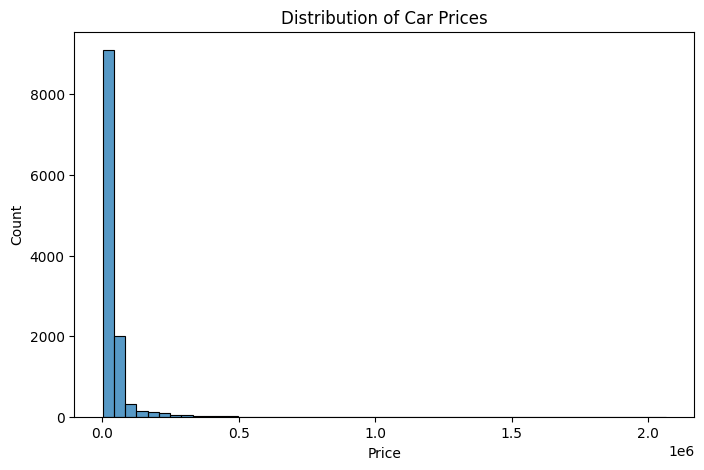

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (8,5))

sns. histplot(df["MSRP"], bins = 50)

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.savefig("../images/price_distribution.png")
plt.show()


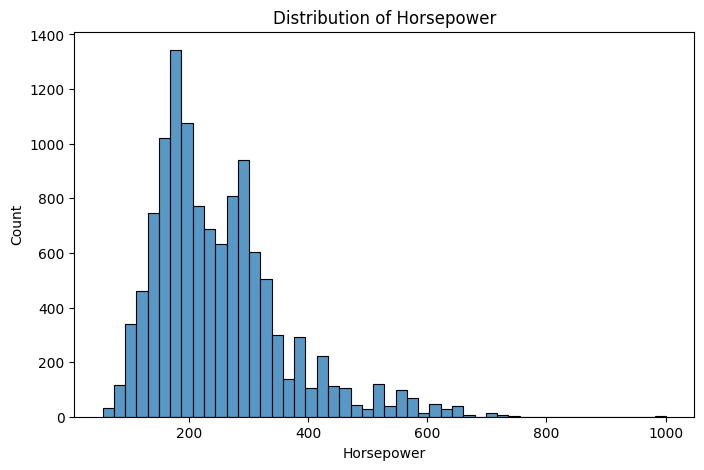

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df["Engine HP"], bins=50)

plt.title("Distribution of Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Count")

plt.savefig("../images/hp_distribution.png")
plt.show()

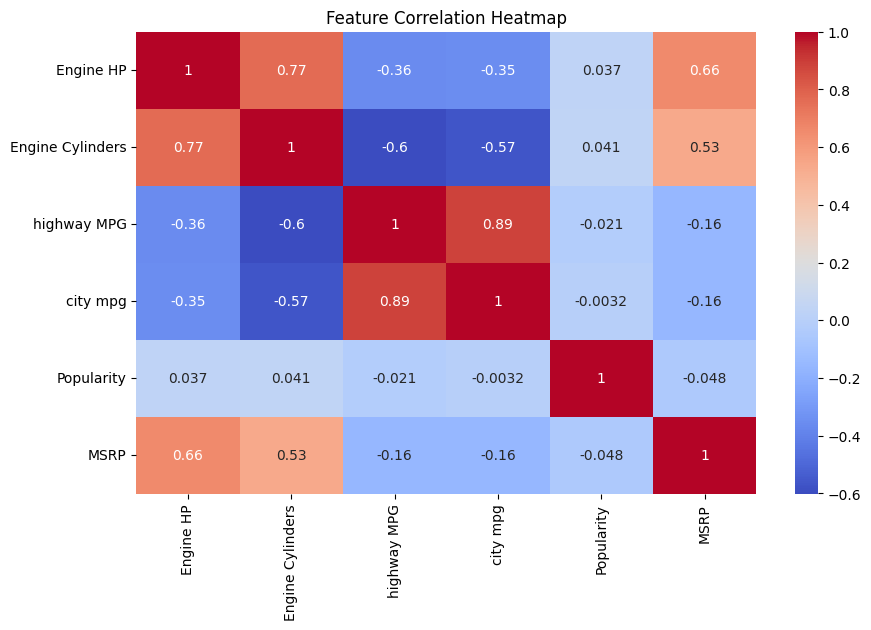

In [42]:
plt.figure(figsize=(10,6))

corr = df[[
    "Engine HP",
    "Engine Cylinders",
    "highway MPG",
    "city mpg",
    "Popularity",
    "MSRP"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png")
plt.show()

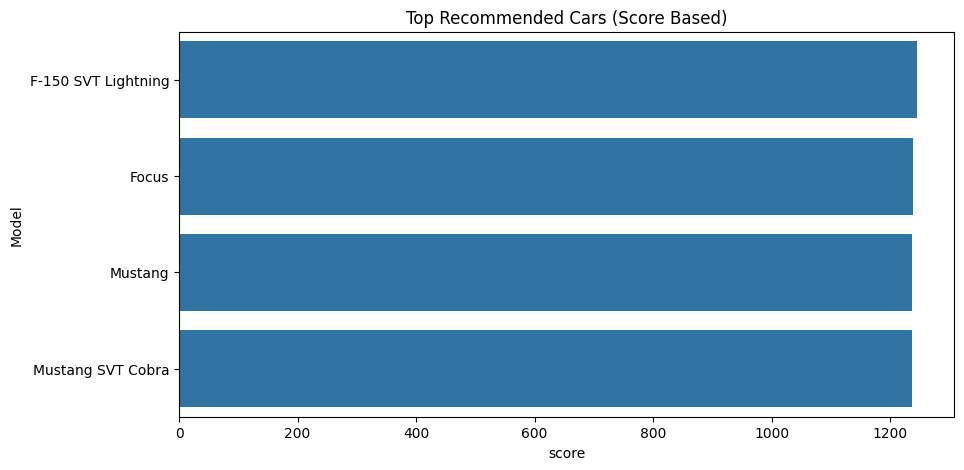

In [43]:
subset = df[df["MSRP"] <= 30000].copy()

subset["score"] = (
    subset["highway MPG"] * 0.4 +
    subset["Engine HP"] * 0.3 +
    subset["Popularity"] * 0.2 -
    subset["MSRP"] * 0.00001
)

top = subset.sort_values(by="score", ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top["score"], y=top["Model"])

plt.title("Top Recommended Cars (Score Based)")
plt.savefig("../images/top_ranked_cars.png")
plt.show()

In [44]:
mkdir -p model

In [45]:
import joblib

joblib.dump(scaler, "../model/scaler.pkl")
joblib.dump(df, "../model/cleaned_car_data.pkl")

print("Artifacts saved.")

Artifacts saved.


In [46]:
def interactive_recommender():

    print("Car Recommendation System")
    print("-------------------------")

    max_price = float(input("Enter your max budget: "))
    min_hp = float(input("Enter your minimum horsepower: "))
    min_mpg = float(input("Enter minimim highway MPG: "))

    recommend_by_preferences(
        max_price = max_price,
        min_hp = min_hp,
        min_mpg = min_mpg
    )

In [48]:
interactive_recommender()

Car Recommendation System
-------------------------

Recommended Cars Based on Preferences:

Chevrolet Caprice
Price: $2000
HP: 260.0
Highway MPG: 24
----------------------------------------
Chrysler LHS
Price: $2000
HP: 253.0
Highway MPG: 24
----------------------------------------
Lincoln Mark VIII
Price: $2000
HP: 280.0
Highway MPG: 24
----------------------------------------
Lincoln Mark VIII
Price: $2000
HP: 280.0
Highway MPG: 24
----------------------------------------
Buick Roadmaster
Price: $2000
HP: 260.0
Highway MPG: 24
----------------------------------------
